# Stock Price Prediction & Anomaly Detection using LSTM
This notebook implements the data processing and modeling pipeline for predicting stock prices in the Indian banking sector (SBI, HDFC, ICICI).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Create results directory
os.makedirs("../results/plots", exist_ok=True)

## 1. Exploratory Data Analysis (EDA)
In this section, we load the raw historical data and visualize the closing price trends for each bank.

--- EDA for SBI ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


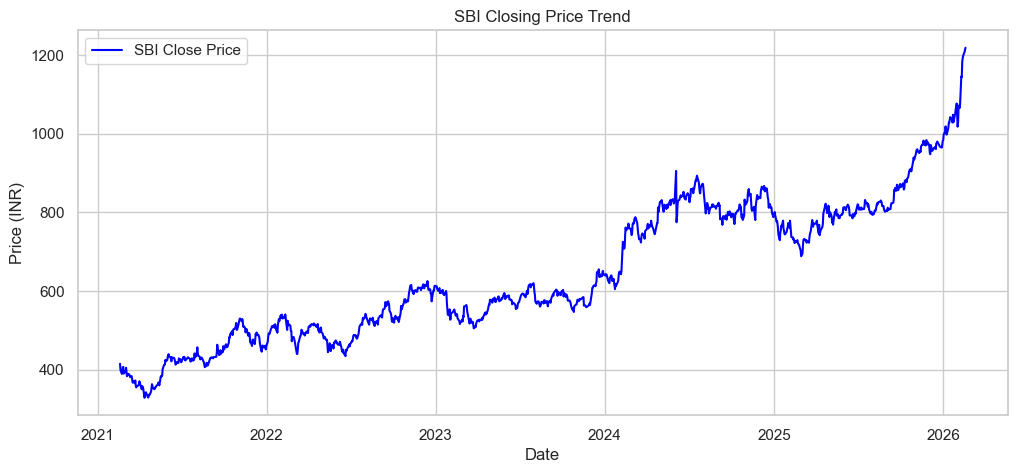

--- EDA for HDFC ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


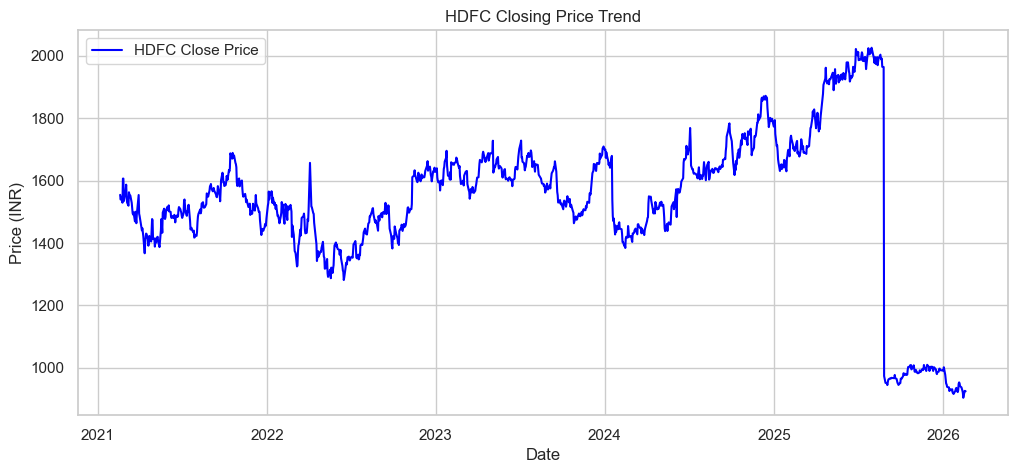

--- EDA for ICICI ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


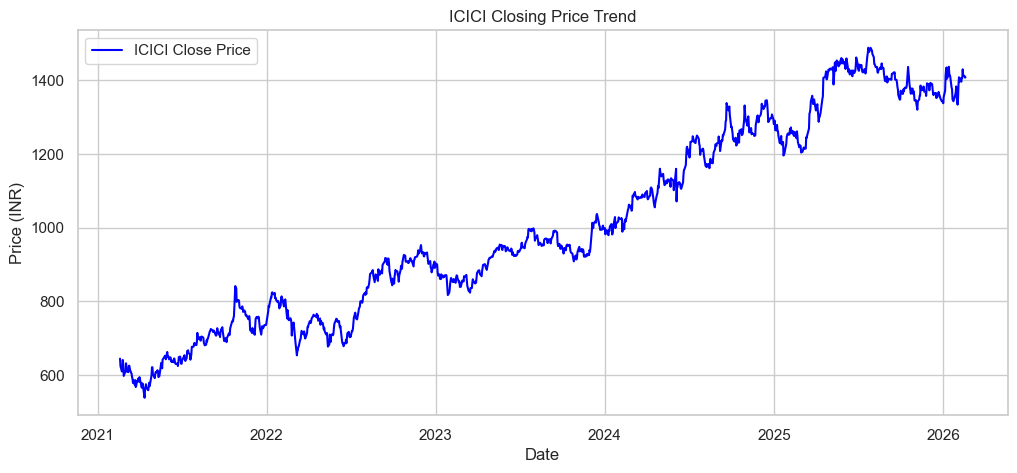

In [8]:
def perform_eda(file_path, bank_name):
    print(f"--- EDA for {bank_name} ---")
    df = pd.read_csv(file_path, thousands=',')
    
    # Preprocessing for EDA: Convert DATE to datetime and sort
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    
    print(f"Data range: {df['DATE'].min()} to {df['DATE'].max()}")
    print(f"Total records: {len(df)}")
    
    # Plotting Closing Price
    plt.figure(figsize=(12, 5))
    plt.plot(df['DATE'], df['CLOSE'], label=f'{bank_name} Close Price', color='blue')
    plt.title(f'{bank_name} Closing Price Trend')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.show()

# Paths to raw data
banks = {'SBI': '../data/raw/SBI.csv', 'HDFC': '../data/raw/HDFC.csv', 'ICICI': '../data/raw/ICICI.csv'}

for name, path in banks.items():
    if os.path.exists(path):
        perform_eda(path, name)
    else:
        print(f"File not found: {path}")

## 2. Correlation Analysis
We analyze the correlation between the three banking stocks to understand their interdependencies.

--- Sectoral Correlation Analysis ---
Aligned records for correlation: 1241


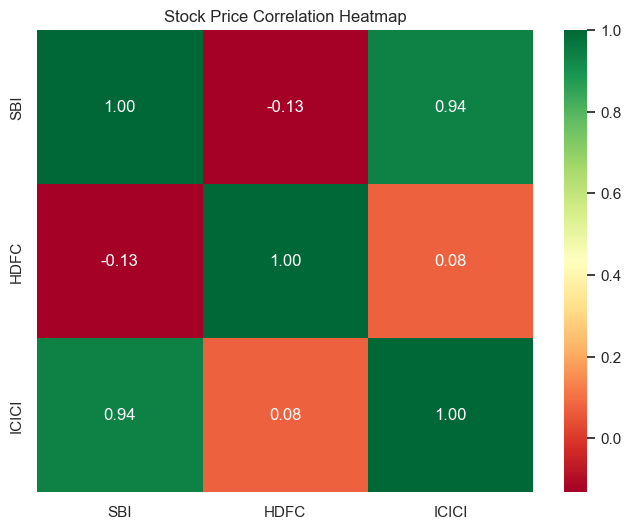

In [9]:
print("--- Sectoral Correlation Analysis ---")
close_prices = {}

for name, path in banks.items():
    if os.path.exists(path):
        df = pd.read_csv(path, thousands=',')
        df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
        df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
        df = df.dropna().groupby('DATE').mean(numeric_only=True) # Handle duplicates
        close_prices[name] = df['CLOSE']

# Combine and calculate correlation matrix
combined_df = pd.concat(close_prices.values(), axis=1, keys=close_prices.keys(), join='inner')
print(f"Aligned records for correlation: {len(combined_df)}")

if not combined_df.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(combined_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title('Stock Price Correlation Heatmap')
    plt.show()

## 3. Data Cleaning & Preprocessing
In this section, we clean the data for SBI (our primary target for prediction) and prepare it for the LSTM model.
Tasks:
- Drop unused columns.
- Normalize data using MinMaxScaler.
- Create sliding window sequences for LSTM input.

In [10]:
def prepare_data(file_path, target_col='CLOSE', window_size=60):
    print(f"--- Preparing data from {file_path} ---")
    df = pd.read_csv(file_path, thousands=',')
    
    # 1. Cleaning: Convert date, sort, and handle duplicates
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
    df = df.dropna(subset=[target_col])
    df = df.groupby('DATE').mean(numeric_only=True) # Ensure one record per day
    
    data = df[target_col].values.reshape(-1, 1)
    
    # 2. Normalization: Scale features to (0, 1) range for LSTM efficiency
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    # 3. Sliding Window Creation
    X, y = [], []
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # LSTM input format: [samples, time steps, features]
    
    print(f"Processed {len(y)} sequences with window size {window_size}")
    return X, y, scaler

# Prepare training sequences for SBI stock
X_sbi, y_sbi, sbi_scaler = prepare_data('../data/raw/SBI.csv', window_size=60)

print(f"X_sbi shape: {X_sbi.shape}")
print(f"y_sbi shape: {y_sbi.shape}")

--- Preparing data from ../data/raw/SBI.csv ---
Processed 1181 sequences with window size 60
X_sbi shape: (1181, 60, 1)
y_sbi shape: (1181,)


## 4. LSTM Model Architecture
Here we define our LSTM model with 3 stacked LSTM layers and Dropout for regularization.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def create_lstm_model(input_shape):
    model = Sequential()
    # First LSTM layer
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # Second LSTM layer
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Third LSTM layer
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    
    # Output layer
    model.add(Dense(units=1))
    
    # Compile the model with Adam optimizer and Mean Squared Error loss
    # Compile the model with Adam optimizer (lr=0.001) and Mean Squared Error loss
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse', 'mae'])
    return model

input_shape = (X_sbi.shape[1], X_sbi.shape[2])
model = create_lstm_model(input_shape)
model.summary()

c:\Users\ronad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training Setup
Next, we configure the hyperparameters (epochs, batch size) and set up the callbacks for EarlyStopping and ModelCheckpoint. Then we train the model.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

epochs = 50
batch_size = 32

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('../results/sbi_lstm_model.h5', monitor='val_loss', save_best_only=True)

print("Starting model training for SBI...")
history = model.fit(
    X_sbi, y_sbi,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Starting model training for SBI...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - loss: 0.0381

34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 503ms/step - loss: 0.0177 - val_loss: 0.0349
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.0034

34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 315ms/step - loss: 0.0030 - val_loss: 0.0101
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 0.0022

34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - loss: 0.0021 - val_loss: 0.0059
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - loss: 0.0020

34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 304ms/step - loss: 0.0021 - val_loss: 0.0039
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 0.0020

34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 319ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - loss: 0.0020 - val_loss: 0.0060
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.0018

34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 425ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 344ms/step - loss: 0.0017 - val_loss: 0.0027
Epoch 13/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 14/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 636ms/step - loss: 0.0017 - val_loss: 0.0089
Epoch 15/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 684ms/step - loss: 0.0019 - val_loss: 0.0057
Epoch 16/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 587ms/step - loss: 0.0013 - val_loss: 0.0068
Epoch 17/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - loss: 0.0017 - val_loss: 0.0017
